# Analyse network results for Pypsa-Earth-Sec
This notebook processes the latest optimization data specified in the config.yaml file and the network .nc file. It generates comprehensive plots and summaries to visualize the results.

Sources: 
- Statistics module: https://pypsa.readthedocs.io/en/latest/examples/statistics.html
- Templates and colors: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/network_analysis.ipynb

File is needed:
* PyPSA network file (.nc) includes the heating, transprot, and electricity demand information.

## Import packages

In [1]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import os

## Path settings
This section reads the config parameters from your config.yaml file and automatically reads the output of the optimization with those settings

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)
# Set your pypsa-earth-sec directory here
PARENT = os.path.realpath("../../pypsa-earth") + "/"
# Set your network path (.nc) here
network_path = PARENT + f"results/try-1/postnetworks/elec_s_16_ec_lcopt_Co2L-3H_3H_2030_0.071_AB_10export.nc"
#network_path = PARENT + f"results/elec_s_10_ec_lc3.0_Co2L_3H_2035_0.071_AB_14export.nc"  
n = pypsa.Network(network_path)
config_path = PARENT + f"/config.yaml"
config = yaml.safe_load(open(config_path))

Index(['H2 pipeline not found 11_AC -> not found 4_AC repurposed',
       'H2 pipeline not found 4_AC -> not found 7_AC repurposed',
       'H2 pipeline not found 11_AC -> not found 4_AC',
       'H2 pipeline not found 4_AC -> not found 7_AC'],
      dtype='object', name='name')
Index(['H2 pipeline not found 11_AC -> not found 4_AC repurposed',
       'H2 pipeline not found 4_AC -> not found 7_AC repurposed',
       'H2 pipeline not found 11_AC -> not found 4_AC',
       'H2 pipeline not found 4_AC -> not found 7_AC'],
      dtype='object', name='name')
INFO:pypsa.io:Imported network elec_s_16_ec_lcopt_Co2L-3H_3H_2030_0.071_AB_10export.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Data import check

List number of components by type

In [3]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 388 entries
Component 'Carrier' has 38 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 22 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 1000 entries
Component 'Load' has 491 entries
Component 'Generator' has 594 entries
Component 'StorageUnit' has 2 entries
Component 'Store' has 259 entries


## Tryout: Show constraint

In [4]:
n.global_constraints

,sense,constant,mu,type,investment_period,carrier_attribute
GlobalConstraint,,,,,,
CO2Limit,<=,77500000.0,-7.606183e-14,primary_energy,NaN,co2_emissions


List the snapshots of the PyPSA network

In [5]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00', '2013-01-01 09:00:00',
               '2013-01-01 12:00:00', '2013-01-01 15:00:00',
               '2013-01-01 18:00:00', '2013-01-01 21:00:00',
               '2013-01-02 00:00:00', '2013-01-02 03:00:00',
               ...
               '2013-12-30 18:00:00', '2013-12-30 21:00:00',
               '2013-12-31 00:00:00', '2013-12-31 03:00:00',
               '2013-12-31 06:00:00', '2013-12-31 09:00:00',
               '2013-12-31 12:00:00', '2013-12-31 15:00:00',
               '2013-12-31 18:00:00', '2013-12-31 21:00:00'],
              dtype='datetime64[ns]', name='snapshot', length=2920, freq=None)
Time steps: 2920


## Analyse energy system

### Transport Sector 
The demand of EVs, ICE (internal combustion engine) and FCEV (fuell cell)

In [ ]:
load_stats = n.statistics.energy_balance(comps=["Load"], aggregate_time="sum")
transport_stats_GWh = load_stats[load_stagts.index.get_level_values('carrier').str.contains(
    'land transport oil(?! emissions)|land transport fuel cell|land transport EV', 
    case=True)]
transport_stats_GWh

component  carrier                   bus_carrier
Load       land transport EV         Li ion           2217.916209
           land transport fuel cell  H2               4422.877731
           land transport oil        oil            722403.362704
Name: objective, dtype: float64

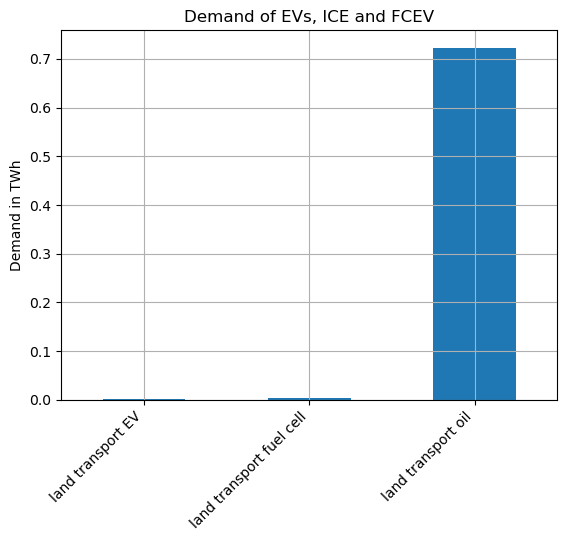

In [7]:
transport_stats_TWh = transport_stats_GWh/1000000

ax = transport_stats_TWh.plot.bar(
    title='Demand of EVs, ICE and FCEV',
    xlabel="",
    ylabel="Demand in TWh"
)

ax.set_xticklabels(transport_stats_GWh.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True) 
plt.show()

### Heating Sector 
The demand of various heating subsectors

In [8]:
load_stats = n.statistics.energy_balance(comps=["Load"], aggregate_time="sum")
heating_stats_GWh = load_stats[load_stats.index.get_level_values('carrier').str.contains('heat', case=False)]
heating_stats_GWh

component  carrier                           bus_carrier                     
Load       residential rural heat            residential rural heat               -0.016785
           residential urban decentral heat  residential urban decentral heat     -0.021856
           urban central heat                urban central heat                 -266.841140
Name: objective, dtype: float64

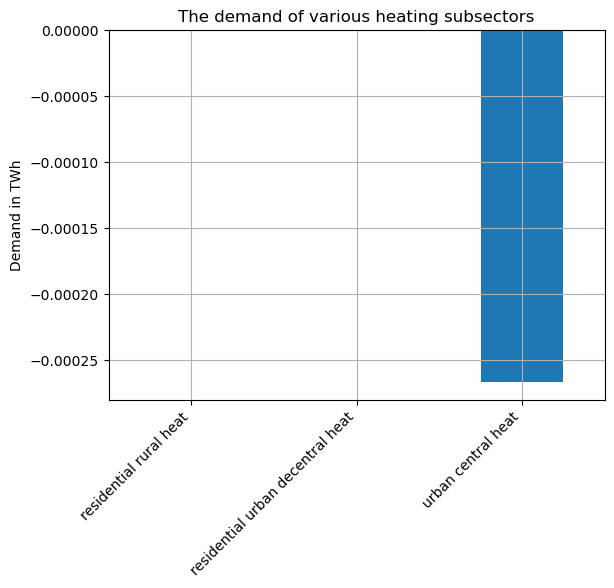

In [9]:
heating_stats_TWh = heating_stats_GWh/1000000

ax = heating_stats_TWh.plot.bar(
    title='The demand of various heating subsectors',
    xlabel="",
    ylabel="Demand in TWh"
)

ax.set_xticklabels(heating_stats_TWh.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True)
plt.show()

How is heating energy supplied (heat pump, district heating, resistive heater, gas boiler)

Gas Boiler: 1.5363321846359597 MWh
Heat Pump: 252.9350758884612 MWh
Resistive Heater: 18.31077459207863 MWh
CHP: 0.993089062701111 MWh


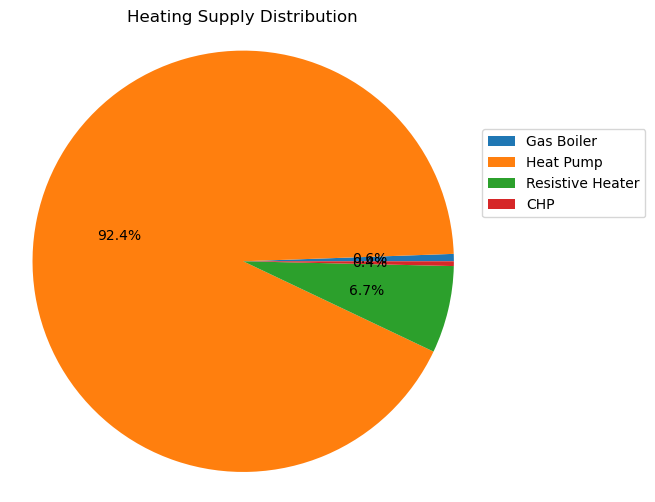

In [10]:
heating_supply_stats = n.statistics.supply(comps=["Link"], aggregate_time="sum").loc[
    lambda x: x.index.get_level_values('carrier').str.contains('heat|boiler|pump|chp', case=False)
]

# Only the Gas boiler, heat pump, CHP, and resistive heater technologies are considered here
heating_types = ['Gas Boiler', 'Heat Pump', 'Resistive Heater', 'CHP']
heating_sums = [heating_supply_stats[heating_supply_stats.index.get_level_values('carrier').str.contains(heatingtype, case=False)].sum() for heatingtype in heating_types]

for ht, sum_value in zip(heating_types, heating_sums):
    print(f"{ht}: {sum_value} MWh")

plt.figure(figsize=(6, 6))
plt.pie(heating_sums, autopct='%1.1f%%')
plt.title('Heating Supply Distribution')
plt.legend(heating_types, loc='upper left', bbox_to_anchor=(1, 0.8))
plt.axis('equal')
plt.show()

### Electricity Sector 
The share of different carriers (capacity and energy)

In [11]:
def color_matching(stats):
    colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
    nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}
    color_list = []
    for carrier in stats.index.get_level_values("carrier"):
        original_name = carrier.lower()
        key_name = nice_names.get(original_name, original_name)
        color = colors.get(key_name.lower(), 'gray')
        color_list.append(color)
    return color_list

In [12]:
capacity_stats = n.statistics.installed_capacity(comps=["Generator"])
# Remove carrier with the capacity = 0
capacity_stats_non_zero = capacity_stats[capacity_stats != 0].dropna()
capacity_stats_plus = n.statistics.installed_capacity(comps=["StorageUnit"])
combined_capacity_stats = pd.concat([capacity_stats_non_zero, capacity_stats_plus])
combined_capacity_stats

component    carrier           
Generator    Combined-Cycle Gas    3.952155e+03
             Run of River          1.600000e+02
             Solar                 1.678100e+02
             load                  3.880000e+11
StorageUnit  Reservoir & Dam       1.424000e+03
Name: p_nom, dtype: float64

In [13]:
n.generators

,carrier,bus,p_nom_min,p_nom,p_nom_extendable,efficiency,marginal_cost,capital_cost,p_nom_max,weight,...,shut_down_cost,stand_by_cost,min_up_time,min_down_time,up_time_before,down_time_before,ramp_limit_up,ramp_limit_down,ramp_limit_start_up,ramp_limit_shut_down
Generator,,,,,,,,,,,,,,,,,,,,,
GH0 0 onwind,onwind,GH0 0,0.00000,0.000000e+00,True,1.0,0.024920,109295.569252,1.128491e+05,6936.813385,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 0 solar,solar,GH0 0,56.22126,5.622126e+01,True,1.0,0.020793,38283.380189,1.516857e+05,22970.357469,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 1 offwind-ac,offwind-ac,GH0 1,0.00000,0.000000e+00,True,1.0,0.024380,191414.330263,0.000000e+00,0.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 1 offwind-dc,offwind-dc,GH0 1,0.00000,0.000000e+00,True,1.0,0.024412,236763.877190,6.423719e+04,7152.149733,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 1 onwind,onwind,GH0 1,0.00000,0.000000e+00,True,1.0,0.025034,109295.569252,7.097459e+03,346.964057,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GH0 6 home battery load,load,GH0 6 home battery,0.00000,1.000000e+09,False,1.0,100.009491,0.000000,inf,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 7 home battery load,load,GH0 7 home battery,0.00000,1.000000e+09,False,1.0,100.010289,0.000000,inf,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0
GH0 8 home battery load,load,GH0 8 home battery,0.00000,1.000000e+09,False,1.0,100.010905,0.000000,inf,1.000000,...,0.0,0.0,0,0,1,0,NaN,NaN,1.0,1.0


In [14]:
print(n.generators.groupby('carrier').p_nom.sum())

carrier
CCGT                                         3.952155e+03
biomass                                      0.000000e+00
coal                                         0.000000e+00
gas                                          0.000000e+00
lignite                                      0.000000e+00
load                                         3.880000e+11
offwind-ac                                   0.000000e+00
offwind-dc                                   0.000000e+00
oil                                          0.000000e+00
onwind                                       0.000000e+00
residential rural solar thermal              0.000000e+00
residential urban decentral solar thermal    0.000000e+00
ror                                          1.600000e+02
services rural solar thermal                 0.000000e+00
services urban decentral solar thermal       0.000000e+00
solar                                        1.678100e+02
solar rooftop                                0.000000e+00
urban 

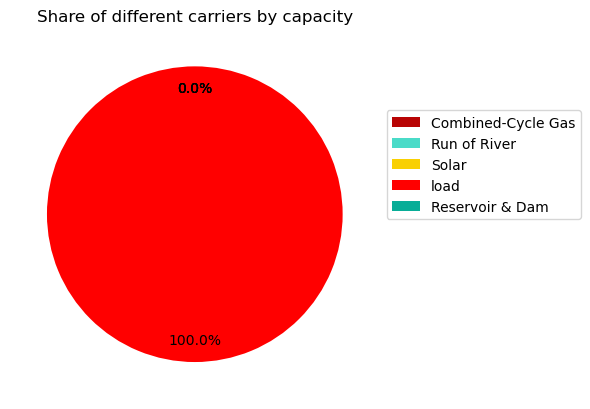

In [15]:
color_list = color_matching(combined_capacity_stats)

combined_capacity_stats.plot.pie(
    title="Share of different carriers by capacity",
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=90,
    ylabel="",
    colors=color_list,
)

custom_labels = combined_capacity_stats.index.get_level_values("carrier")
plt.legend(custom_labels, loc='upper left', bbox_to_anchor=(1, 0.8))


## Tryout: Get rid of load

In [16]:
combined_capacity_stats_v2 = combined_capacity_stats[
    combined_capacity_stats.index.get_level_values("carrier") != "load"
]

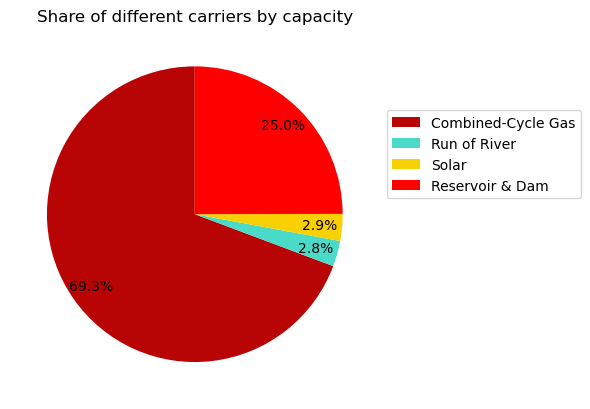

In [17]:
color_list = color_matching(combined_capacity_stats)

combined_capacity_stats_v2.plot.pie(
    title="Share of different carriers by capacity",
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=90,
    ylabel="",
    colors=color_list,
)

custom_labels = combined_capacity_stats_v2.index.get_level_values("carrier")
plt.legend(custom_labels, loc='upper left', bbox_to_anchor=(1, 0.8))

In [18]:
energy_stats = n.statistics.energy_balance(comps=["Generator"])
electricity_energy_stats = energy_stats[energy_stats.index.get_level_values('bus_carrier') == 'AC']
electricity_energy_stats_plus = n.statistics.energy_balance(comps=["StorageUnit"])
combined_electricity_energy_stats = pd.concat([electricity_energy_stats, electricity_energy_stats_plus])
combined_electricity_energy_stats

component    carrier             bus_carrier
Generator    Combined-Cycle Gas  AC             1.945633e-02
             Offshore Wind (DC)  AC             4.699012e-03
             Onshore Wind        AC             1.578306e-02
             Run of River        AC             1.401600e+06
             Solar               AC             2.226762e+05
             load                AC             3.511865e-05
StorageUnit  Reservoir & Dam     AC             5.196118e+06
dtype: float64

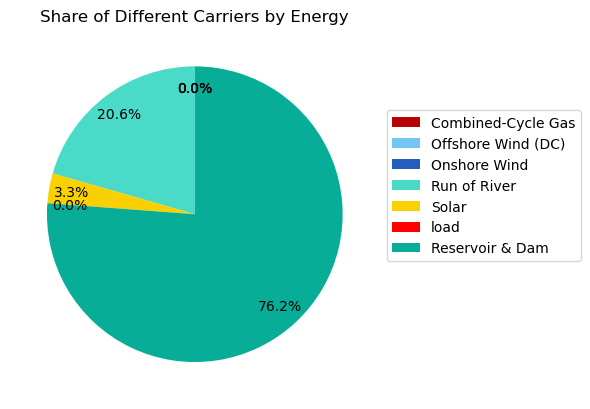

In [19]:
color_list = color_matching(combined_electricity_energy_stats)

combined_electricity_energy_stats.plot.pie(
    title='Share of Different Carriers by Energy',
    labels=None,
    autopct='%1.1f%%',
    pctdistance=0.85,
    startangle=90,
    ylabel="",
    colors=color_list,  
)

custom_labels = combined_electricity_energy_stats.index.get_level_values("carrier")
plt.legend(custom_labels, loc='upper left', bbox_to_anchor=(1, 0.8))

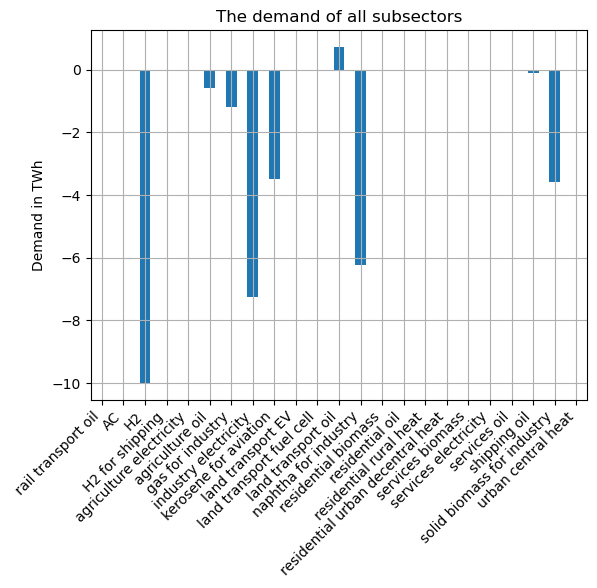

In [44]:
load_stats_TWh = load_stats / 1000000

energy_load_stats_TWh = load_stats_TWh[~load_stats.index.get_level_values('bus_carrier').str.contains('co2|process emissions', case=False)] 

ax = energy_load_stats_TWh.plot.bar(
    title='The demand of all subsectors',
    xlabel="",
    ylabel="Demand in TWh"
)

ax.set_xticklabels(energy_load_stats_TWh.index.get_level_values('carrier'), rotation=45, ha="right")
ax.grid(True)
plt.show()


In [43]:
print(energy_load_stats_TWh.index.get_level_values('bus_carrier'))

Index(['oil', 'low voltage', 'H2', 'H2', 'low voltage', 'oil',
       'gas for industry', 'low voltage', 'oil', 'Li ion', 'H2', 'oil', 'oil',
       'process emissions', 'biomass', 'oil', 'residential rural heat',
       'residential urban decentral heat', 'biomass', 'low voltage', 'oil',
       'oil', 'solid biomass for industry', 'urban central heat'],
      dtype='object', name='bus_carrier')


In [38]:
load_stats.index.get_level_values('bus_carrier')

Index(['oil', 'low voltage', 'H2', 'H2', 'low voltage', 'oil',
       'gas for industry', 'low voltage', 'co2', 'oil', 'Li ion', 'H2', 'oil',
       'co2', 'oil', 'co2', 'process emissions', 'biomass', 'oil',
       'residential rural heat', 'residential urban decentral heat', 'biomass',
       'low voltage', 'oil', 'oil', 'solid biomass for industry',
       'urban central heat'],
      dtype='object', name='bus_carrier')

In [46]:
load_stats_TWh

component  carrier                           bus_carrier                     
Load        rail transport oil               oil                                -1.689907e-02
           AC                                low voltage                        -4.221998e-03
           H2                                H2                                 -1.000000e+01
           H2 for shipping                   H2                                 -4.450793e-03
           agriculture electricity           low voltage                        -1.399444e-02
           agriculture oil                   oil                                -5.723683e-01
           gas for industry                  gas for industry                   -1.192491e+00
           industry electricity              low voltage                        -7.241623e+00
           industry oil emissions            co2                                 1.603060e+00
           kerosene for aviation             oil                            

carrier
CCGT                                         1.945633e-08
biomass                                      3.586412e+00
coal                                         0.000000e+00
gas                                          1.435265e+01
lignite                                      0.000000e+00
load                                         3.589789e-07
offwind-ac                                   0.000000e+00
offwind-dc                                   4.699012e-09
oil                                          6.897908e-08
onwind                                       1.578306e-08
residential rural solar thermal              3.680817e-08
residential urban decentral solar thermal    3.652499e-08
ror                                          1.401600e+00
services rural solar thermal                 3.673054e-08
services urban decentral solar thermal       4.173115e-08
solar                                        2.226762e-01
solar rooftop                                1.246533e-07
urban 

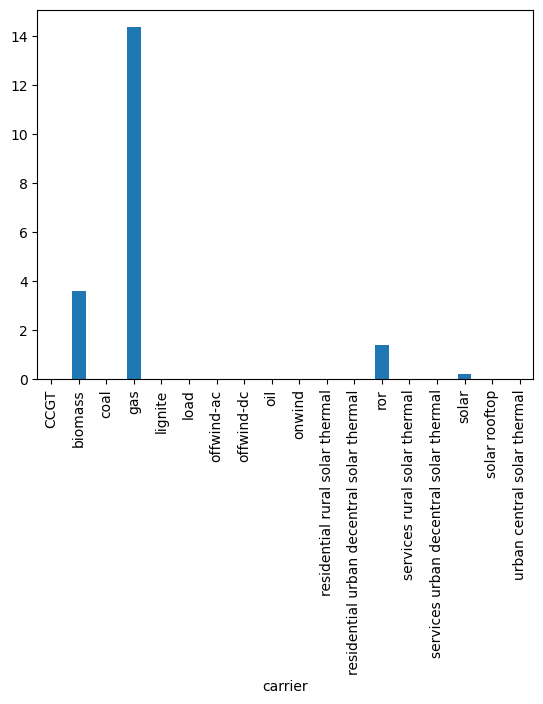

In [51]:
# Sum total electricity generation per carrier
generation = n.generators_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum()

# Group by carrier (e.g., solar, wind, coal)
total_generation_per_carrier_TWh = generation.groupby(n.generators.carrier).sum() / 1000000

print(total_generation_per_carrier_TWh)

total_generation_per_carrier_TWh.plot.bar()

print(total_generation_per_carrier_TWh.sum())

In [60]:
total_consumption_perLoad = n.loads_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum()

# Sum across all buses
total_consumption = total_consumption_perLoad.sum()

print(f"Total energy consumption: {total_consumption} MWh")
total_consumption_perLoad

Total energy consumption: 23656170.13345942 MWh


Load
GH0 0                              367.561184
GH0 0 H2 for industry                0.000000
GH0 0 H2 for shipping                0.000000
GH0 0 agriculture electricity     1259.557197
GH0 0 agriculture oil            51515.500755
                                     ...     
residential gas emissions            0.000000
residential oil emissions         -112.121562
services gas emissions               0.000000
services oil emissions             -14.565032
shipping oil emissions               0.000000
Length: 491, dtype: float64

In [57]:
total_storage = n.stores_t.p.multiply(n.snapshot_weightings.generators, axis=0).sum()

print(total_storage.sum() / 1000000)

-0.39407191901028066
